# Independent Cascade (IC) on an Erdős–Rényi Graph

This notebook builds intuition for the **Independent Cascade (IC)** diffusion model by running it on a small **Erdős–Rényi random graph G(N, p_ER)**, where each possible edge exists independently with probability `p_ER`.

---

## What is the Independent Cascade model?

The IC model simulates how information (or infection) spreads through a network **wave by wave**:

1. Start with a single **source node** (Patient Zero) that is infected at time `t=0`.
2. At each timestep, every **newly** infected node gets **one chance** to infect each of its susceptible neighbours.
3. The infection attempt succeeds with probability **`p`** — independently for each edge.
4. Once a node either successfully infects a neighbour or fails to, that edge is **burned** (no retries in future rounds).
5. The process terminates when there are no newly infected nodes.

The result is a **cascade** — a set of infected nodes and the directed edges that transmitted the infection.

---

## Why an Erdős–Rényi Graph?

An Erdős–Rényi graph `G(N, p_ER)` is the simplest **random** network: every pair of nodes is connected independently with probability `p_ER`, giving a roughly **homogeneous** degree distribution (Poisson-like around a mean degree of `(N-1)·p_ER`).

This makes it a useful baseline:
- Unlike a complete graph it has **missing edges**, so the IC cascade follows a non-trivial structure.
- Unlike a scale-free (BA) graph it has **no hubs** — every node is approximately equivalent, so structural source-identification has to rely on subtler signals than "largest-degree node".
- Small `N` makes it easy to visualise the full cascade step-by-step.

## ⚙️ Parameters — edit these to experiment

| Parameter | Meaning | Try changing it to... |
|-----------|---------|----------------------|
| `N` | Number of nodes in the ER graph | 10, 20, 50 |
| `ER_P` | Edge probability in `G(N, p_ER)` (controls average degree) | 0.1 (sparse), 0.25 (moderate), 0.5 (dense) |
| `p` | IC transmission probability per edge per timestep | 0.1 (rare), 0.5 (moderate), 1.0 (always infects) |
| `SOURCE` | Which node starts the infection (Patient Zero) | Any integer from 0 to N-1 |
| `SEED` | Random seed for reproducibility | Any integer — change for different stochastic runs |
| `NETWORK_SEED` | Seed for generating the ER graph itself | Any integer — change for a different random structure |
| `R0` | **Alternative**: set R₀ instead of `p` directly — `p` is computed from R₀ | 0.5 (sub-critical), 1.0 (threshold), 2.0 (spreading), 3.0 (aggressive) |

In [1]:
# ── Parameters — change these and re-run! ───────────────────────────────────

N            = 20    # Number of nodes in the ER graph
ER_P         = 0.25  # Edge probability in G(N, p_ER) → avg_degree ≈ (N-1) * ER_P
SOURCE       = 1     # Patient Zero — which node starts the infection
SEED         = 43    # Random seed for the IC simulation
NETWORK_SEED = 42    # Random seed for generating the ER graph structure

# Transmission probability: either set p directly OR set R0 and let us compute p
USE_R0 = True   # Set True to use R0, False to use p directly
R0     = 1      # Basic Reproduction Number (average secondary infections)
p      = 0.3    # Transmission probability per edge (used only if USE_R0 = False)

# ── Derived ─────────────────────────────────────────────────────────────────
# avg_degree for ER(N, p_ER) is (N-1) * p_ER in expectation; we use the empirical value
# below (computed from the actual generated graph) so the R0 → p mapping is exact.

print(f"Setup: ER(N={N}, p_ER={ER_P})  |  Source node={SOURCE}  |  "
      f"IC seed={SEED}  |  Network seed={NETWORK_SEED}")

Setup: ER(N=20, p_ER=0.25)  |  Source node=1  |  IC seed=43  |  Network seed=42


## Step 1 — Build the Erdős–Rényi Graph

In [2]:
import sys
sys.path.insert(0, '..')   # make src/ importable from the notebooks/ folder

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

from src.data.networks import generate_er_network, compute_network_stats

G = generate_er_network(n=N, p=ER_P, seed=NETWORK_SEED)
stats = compute_network_stats(G)

print("Network statistics:")
for k, v in stats.items():
    print(f"  {k:<20} {v}")

# Empirical average degree — used for the R0 → p mapping
avg_degree = stats['avg_degree']
if USE_R0:
    p = min(R0 / avg_degree, 1.0)   # IC mapping: p = R0 / <k>
    print(f"\nR0={R0}  →  p = R0 / avg_degree = {R0} / {avg_degree} = {p:.4f}")
else:
    print(f"\nUsing p={p} directly")

Network statistics:
  name                 Erdos-Renyi
  nodes                20
  edges                56
  avg_degree           5.6
  diameter             3
  clustering           0.2858
  density              0.2947

R0=1  →  p = R0 / avg_degree = 1 / 5.6 = 0.1786


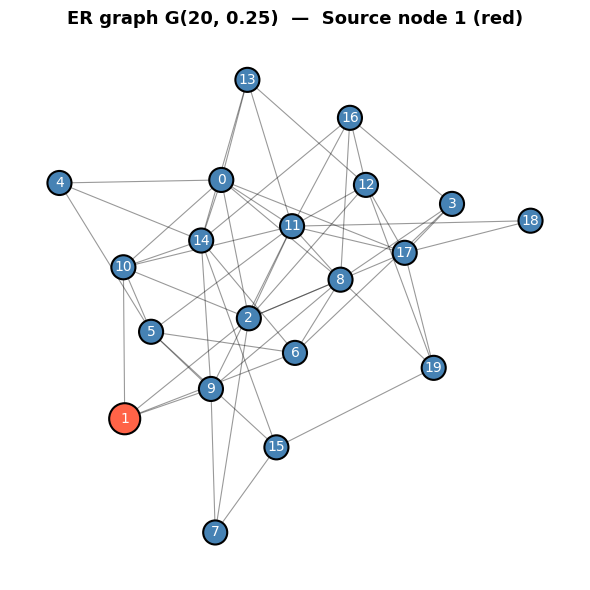

Source node 1 has degree = 4
Graph avg degree = 5.6  (expected ≈ (N-1)·p_ER = 4.75)


In [3]:
# Visualise the base graph with the source node highlighted

pos = nx.spring_layout(G, seed=NETWORK_SEED)

fig, ax = plt.subplots(figsize=(6, 6))
node_colors = ['tomato' if n == SOURCE else 'steelblue' for n in G.nodes()]
node_sizes  = [500 if n == SOURCE else 300 for n in G.nodes()]

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.4, width=0.8)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_color='white')

ax.set_title(f'ER graph G({N}, {ER_P})  —  Source node {SOURCE} (red)',
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

degrees = dict(G.degree())
print(f"Source node {SOURCE} has degree = {degrees[SOURCE]}")
print(f"Graph avg degree = {avg_degree}  (expected ≈ (N-1)·p_ER = {(N-1)*ER_P:.2f})")

## Step 2 — Run the IC Simulation

The `IndependentCascade` model will:
- Start at `SOURCE`
- Each round: newly infected nodes try to infect each susceptible neighbour with probability `p`
- Stop when no new infections occur

The output is a `CascadeResult` object with:
- `result.source` — the true Patient Zero
- `result.infection_times` — `{node: timestep}` for every infected node
- `result.cascade_edges` — directed `(infector → infected)` edges
- `result.observed_graph` — **undirected** version (what an ML model would see)
- `result.size` — number of infected nodes
- `result.depth` — length of the longest infection chain

In [4]:
from src.data.cascade import IndependentCascade

model  = IndependentCascade(p=p)
result = model.run(G, source=SOURCE, seed=SEED)

print(f"=== IC Cascade Result ===")
print(f"  Source (Patient Zero) : {result.source}")
print(f"  Infected nodes        : {result.size} / {N}  ({100*result.size/N:.0f}%)")
print(f"  Cascade depth         : {result.depth} timesteps")
print(f"  Empirical R0          : {result.actual_r0():.2f}")
print(f"\n  Infection timeline:")
by_time = {}
for node, t in sorted(result.infection_times.items(), key=lambda x: x[1]):
    by_time.setdefault(t, []).append(node)
for t, nodes in sorted(by_time.items()):
    label = '← SOURCE' if t == 0 else ''
    print(f"    t={t}: nodes {nodes} {label}")

print(f"\n  Uninfected nodes: {sorted(set(G.nodes()) - set(result.infection_times.keys()))}")

=== IC Cascade Result ===
  Source (Patient Zero) : 1
  Infected nodes        : 10 / 20  (50%)


  Cascade depth         : 6 timesteps
  Empirical R0          : 1.50

  Infection timeline:
    t=0: nodes [1] ← SOURCE
    t=1: nodes [2, 9] 
    t=2: nodes [11] 
    t=3: nodes [0, 12] 
    t=4: nodes [13, 14] 
    t=5: nodes [6] 
    t=6: nodes [5] 

  Uninfected nodes: [3, 4, 7, 8, 10, 15, 16, 17, 18, 19]


## Step 3 — Visualise the Cascade Tree

The **infection tree** shows the **directed** transmission path.
- Red node = Patient Zero (SOURCE)
- Colour = infection time (yellow = early, red = late)
- An edge `A → B` means node A infected node B

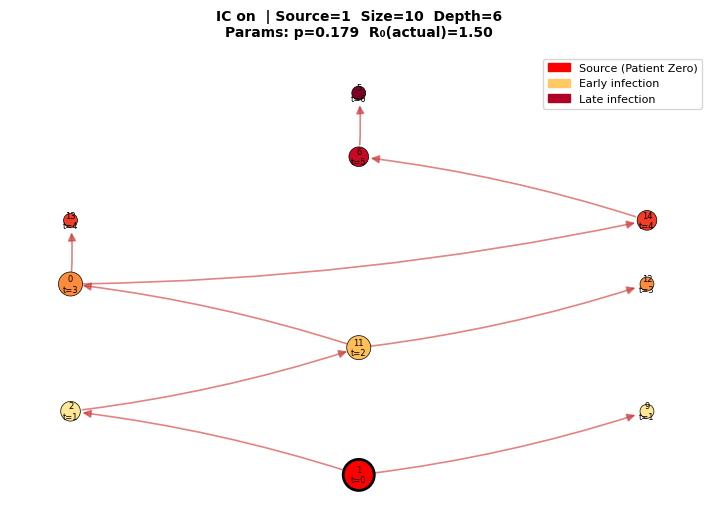

In [5]:
from src.visualization.cascades import plot_cascade_tree

fig = plot_cascade_tree(result, G, figsize=(9, 6))
plt.show()

## Step 4 — Visualise on the Original Network

Here we draw the **ER graph** and colour nodes by their infection status and time.

C:\Users\andre\AppData\Local\Temp\ipykernel_19992\2988203774.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


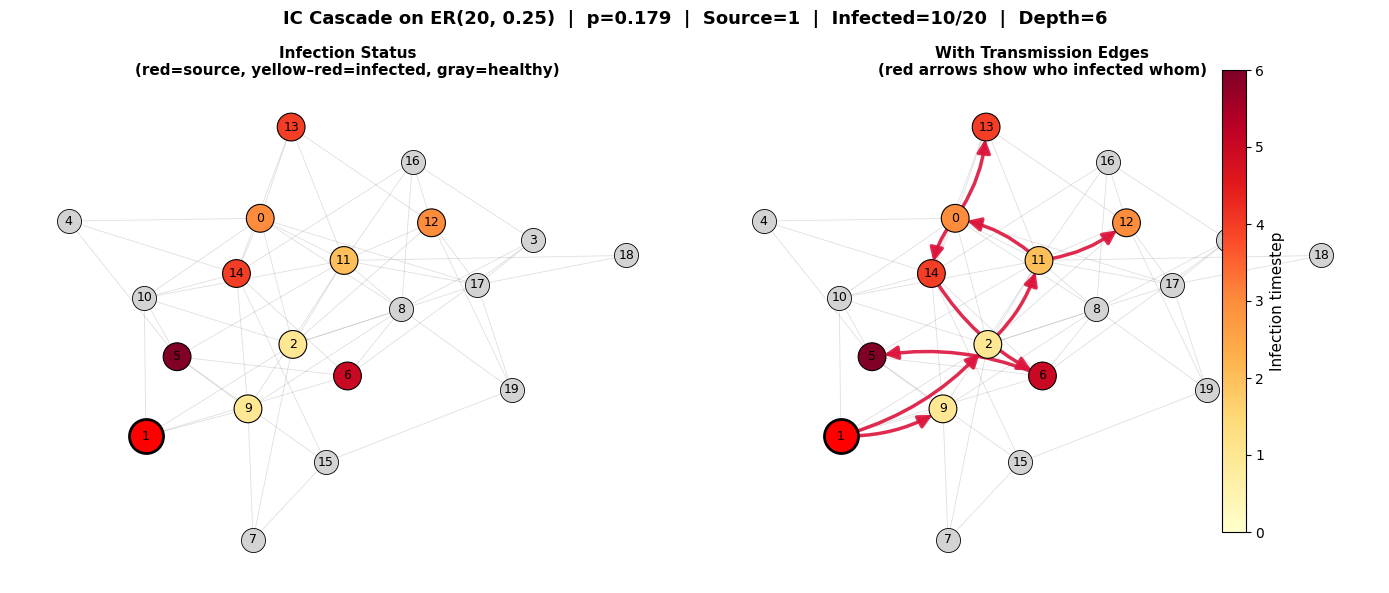

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

times     = result.infection_times
max_t     = max(times.values(), default=1) or 1
cmap      = plt.cm.YlOrRd
norm      = mcolors.Normalize(vmin=0, vmax=max_t)
infected  = set(times.keys())
uninfected = set(G.nodes()) - infected

def draw_network(ax, show_cascade_edges=False):
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.6, edge_color='gray')
    if show_cascade_edges and result.cascade_edges:
        nx.draw_networkx_edges(
            result.infection_tree, pos, ax=ax,
            edge_color='crimson', width=2.5, alpha=0.9,
            arrows=True, arrowsize=20,
            connectionstyle='arc3,rad=0.15',
        )
    # Infected nodes — colour by infection time
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=[n for n in infected if n != SOURCE],
        node_color=[cmap(norm(times[n])) for n in infected if n != SOURCE],
        node_size=400, edgecolors='black', linewidths=0.8,
    )
    # Source node
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[SOURCE],
                           node_color='red', node_size=600,
                           edgecolors='black', linewidths=2)
    # Uninfected nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=list(uninfected),
                           node_color='lightgray', node_size=300,
                           edgecolors='black', linewidths=0.6)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color='black')

# Left: just infection status
draw_network(axes[0], show_cascade_edges=False)
axes[0].set_title(f'Infection Status\n(red=source, yellow–red=infected, gray=healthy)',
                   fontsize=11, fontweight='bold')
axes[0].axis('off')

# Right: with directed cascade edges overlaid
draw_network(axes[1], show_cascade_edges=True)
axes[1].set_title(f'With Transmission Edges\n(red arrows show who infected whom)',
                   fontsize=11, fontweight='bold')
axes[1].axis('off')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.03, pad=0.02).set_label(
    'Infection timestep', fontsize=11)

fig.suptitle(f'IC Cascade on ER({N}, {ER_P})  |  p={p:.3f}  |  Source={SOURCE}  |  '
             f'Infected={result.size}/{N}  |  Depth={result.depth}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5 — Run Many Times to See the Distribution

Because IC is **stochastic**, the same parameters produce different outcomes each run.  
Here we run 200 simulations and look at the distribution of cascade sizes.

In [7]:
N_RUNS = 200   # ← change this

sizes = []
for seed_i in range(N_RUNS):
    r = IndependentCascade(p=p).run(G, source=SOURCE, seed=seed_i)
    sizes.append(r.size)

import numpy as np

print(f"Distribution of cascade sizes over {N_RUNS} runs (p={p:.3f}, ER({N}, {ER_P})):")
print(f"  Mean:   {np.mean(sizes):.1f} / {N}")
print(f"  Median: {np.median(sizes):.1f}")
print(f"  Min:    {min(sizes)}  (only source infected — epidemic died immediately)")
print(f"  Max:    {max(sizes)}  (everyone infected)")
print(f"  Full spread (size={N}): {100*sizes.count(N)/N_RUNS:.0f}% of runs")

Distribution of cascade sizes over 200 runs (p=0.179, ER(20, 0.25)):
  Mean:   3.7 / 20
  Median: 2.0
  Min:    1  (only source infected — epidemic died immediately)
  Max:    16  (everyone infected)
  Full spread (size=20): 0% of runs


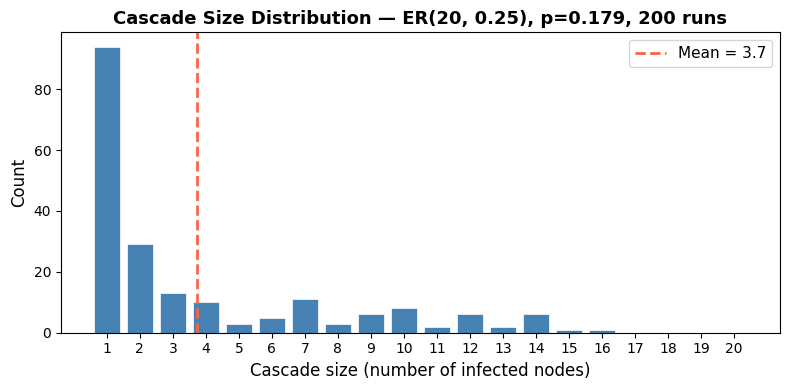

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sizes, bins=range(1, N + 2), align='left', color='steelblue',
        edgecolor='white', linewidth=0.5, rwidth=0.8)
ax.axvline(np.mean(sizes), color='tomato', linewidth=2,
           linestyle='--', label=f'Mean = {np.mean(sizes):.1f}')
ax.set_xlabel('Cascade size (number of infected nodes)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title(f'Cascade Size Distribution — ER({N}, {ER_P}), p={p:.3f}, {N_RUNS} runs',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(range(1, N + 1))
plt.tight_layout()
plt.show()

## Step 6 — Sweep R₀ and see how cascade size changes

This is the core research question: **how does infectiousness (R₀) affect the cascade?**

> R₀ < 1 → epidemic dies out (sub-critical)  
> R₀ = 1 → critical threshold  
> R₀ > 1 → epidemic spreads (super-critical)

R0=0.5  p=0.0893  mean_size=1.7
R0=1.0  p=0.1786  mean_size=3.6
R0=1.5  p=0.2679  mean_size=8.2
R0=2.0  p=0.3571  mean_size=12.8
R0=3.0  p=0.5357  mean_size=18.4
R0=5.0  p=0.8929  mean_size=20.0


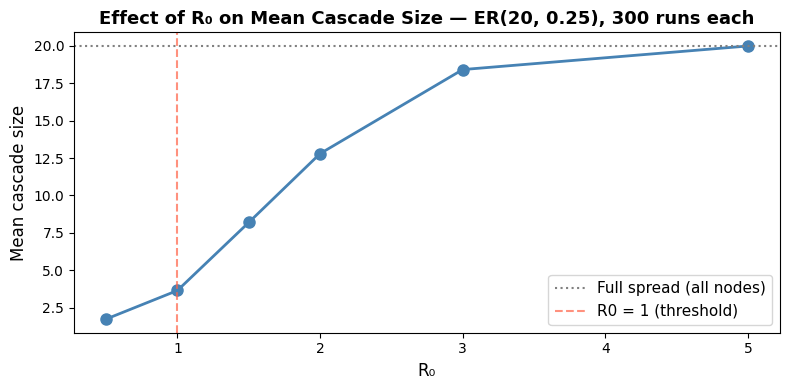

In [9]:
R0_SWEEP  = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]   # ← change the R0 values to sweep
N_RUNS_SW = 300

mean_sizes = []
for r0 in R0_SWEEP:
    p_r0 = min(r0 / avg_degree, 1.0)
    s = [IndependentCascade(p=p_r0).run(G, source=SOURCE, seed=i).size
         for i in range(N_RUNS_SW)]
    mean_sizes.append(np.mean(s))
    print(f"R0={r0:.1f}  p={p_r0:.4f}  mean_size={np.mean(s):.1f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(R0_SWEEP, mean_sizes, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(N, color='gray', linestyle=':', label='Full spread (all nodes)')
ax.axvline(1.0, color='tomato', linestyle='--', alpha=0.7, label='R0 = 1 (threshold)')
ax.set_xlabel('R₀', fontsize=12)
ax.set_ylabel('Mean cascade size', fontsize=12)
ax.set_title(f'Effect of R₀ on Mean Cascade Size — ER({N}, {ER_P}), {N_RUNS_SW} runs each',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## 💡 Things to try

1. **Change `N`** (top of notebook) — how does a larger graph change the cascade shape?
2. **Change `ER_P`** — at `ER_P=0.05` the graph is sparse (tree-like), at `ER_P=0.5` it becomes very dense. How does cascade shape change?
3. **Set `p=1.0`** — with transmission probability 1, IC infects every node in the connected component of the source. Why doesn't it always reach all `N` nodes like on a complete graph?
4. **Set `R0=0.5`** — run 20 times. What fraction of the time does the epidemic die immediately (size=1)?
5. **Change `SOURCE`** — on an ER graph, does the source node matter? (Unlike a complete graph, some nodes will have more neighbours than others — does that bias the cascade?)
6. **Change `NETWORK_SEED`** — regenerates the ER structure. Does a different random wiring change the typical cascade size for fixed `R0`?
7. **Compare** to the complete-graph notebook (`03_IC_on_complete_graph.ipynb`) — for the same `R0`, which network produces larger cascades? Which is more variable?